# Today's Agenda:
* ## `scipy` for solving ODEs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import linalg as la
import scipy.integrate as integ

## Physical Simulation 3: Spring-mass-damper

A classical problem in mechanics:
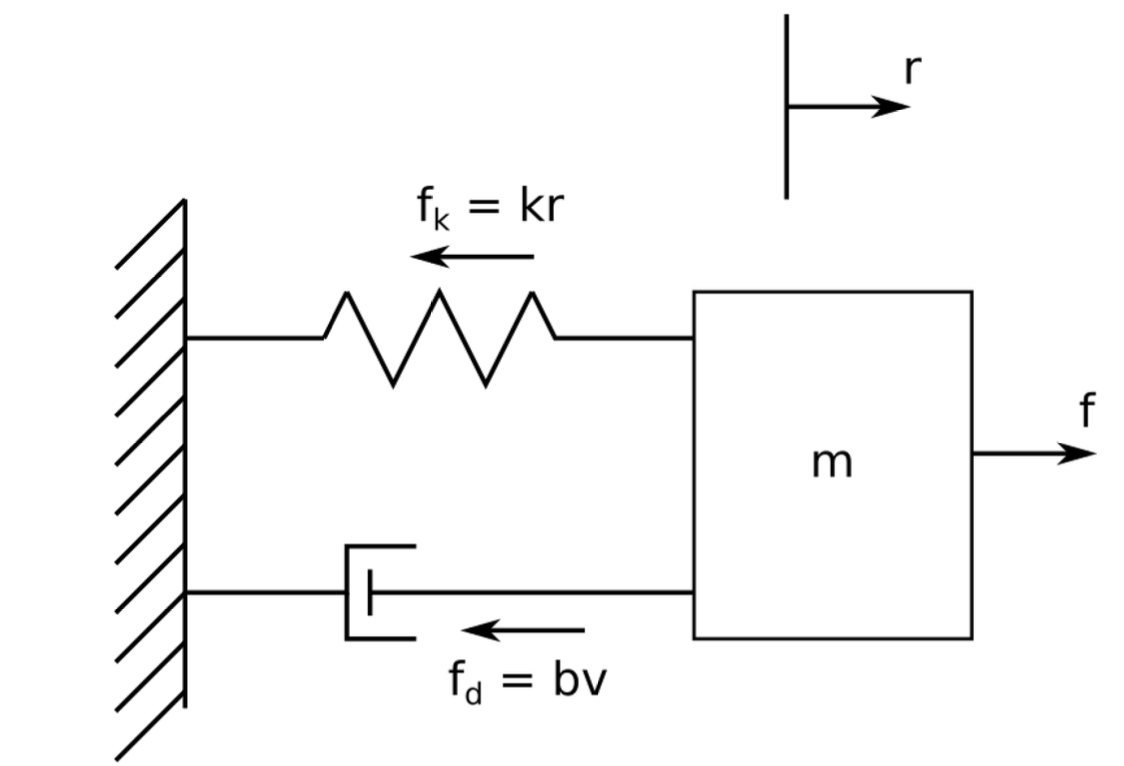


* A mass is attached to a wall by a spring and a viscous damper.
* A force $f$ is applied at the right. Assume no gravity.

* The applied force is opposed by:
  * A spring force $f_k$ with force proportional to the displacement $r$.
  * A damping force $f_d$ with force proportional to the velocity $v$.
  * The inertial force $ma$.

* Governing equation:
$$f-f_k-f_d = ma$$

* Substituting the spring and damper forces:
$$f-kr-bv = ma$$

* As before, substitute:
$$v = \frac{dr}{dt},\quad a = \frac{dv}{dt}$$

* This eliminates a and leaves us with 2 equations:
$$\begin{aligned}
&m\frac{dv}{dt} +kr+bv = f\\
&\frac{dr}{dt} = v
\end{aligned}$$

  * spring coefficient $k = 10$;
  * damper coefficient $b = 2$;
  * mass $m = 1$
  * initial condition $v(t=0) = 0, r(t=0) = 0$
  * constant force $f = 1$
  

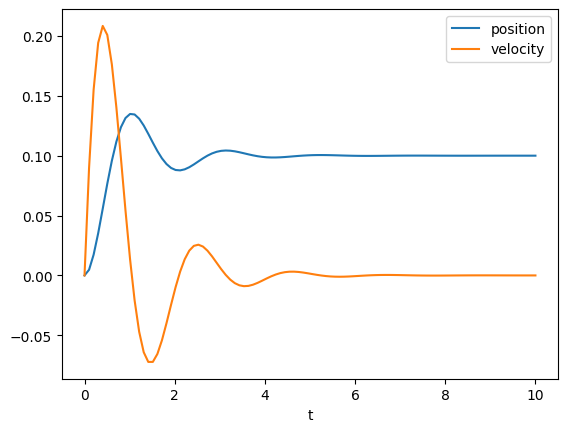

In [ ]:
def spring_mass(y, t):  # def function
    k = 10
    b = 2
    m = 1
    f = 1
    return np.array([y[1], -k/m*y[0]-b/m*y[1]+f/m])


t = np.linspace(0,10,100)

Y = integ.odeint(spring_mass, np.array([0,0]),t )

plt.plot(t,Y[:,0],label = 'position')
plt.plot(t,Y[:,1],label = 'velocity')
plt.legend()
plt.xlabel('t')
plt.show()

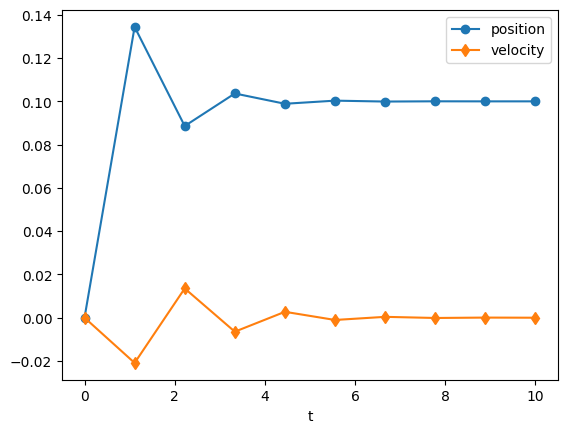

In [ ]:
def spring_mass(y, t):  # def function
    k = 10
    b = 2
    m = 1
    f = 1
    return np.array([y[1], -k/m*y[0]-b/m*y[1]+f/m])


t = np.linspace(0,10,10)

Y = integ.odeint(spring_mass, np.array([0,0]),t )

plt.plot(t,Y[:,0],marker = 'o',label = 'position')
plt.plot(t,Y[:,1],marker = 'd',label = 'velocity')
plt.legend()
plt.xlabel('t')
plt.show()

## Note: we notice that the size of $\Delta t$ has a big effect on solution accuracy. It is usually the case for numerical integration: the smaller $\Delta$ brings in more accurate integration. There are advanced numerical analysis courses on the numerical schemes for solving ODEs (and PDEs).

## Physical Simulation 4: SIR Model for COVID-19

	•	S(t): Number of susceptible people
	•	I(t): Number of infected people
	•	R(t): Number of recovered (or removed) people

\begin{aligned}
\frac{dS}{dt} &= -\beta \cdot \frac{S \cdot I}{N} \\
\frac{dI}{dt} &= \beta \cdot \frac{S \cdot I}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{aligned}

*	$N$ is the total population
*	$\beta$ is the transmission rate
*	$\gamma$ is the recovery rate



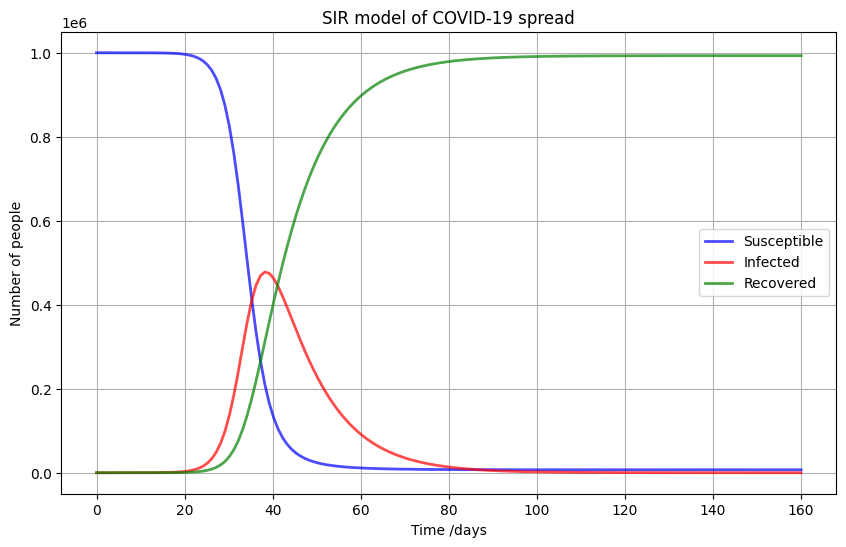

In [ ]:
# Total population, N
N = 1000000
# Contact rate, beta, and mean recovery rate, gamma (in 1/days)
beta = 0.5   # each infected person infects 0.3 people per day
gamma = 1/10 # average infectious period is 10 days


# Initial number of infected and recovered individuals
I0 = 1
R0 = 0
S0 = N - I0 - R0  # Everyone else is susceptible

# A grid of time points (in days)
t = np.linspace(0, 160, 160)

# The SIR model differential equations
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Initial conditions vector
y0 = S0, I0, R0

# Integrate the SIR equations over the time grid
ret = integ.odeint(deriv, y0, t, args=(N, beta, gamma))
S, I, R = ret.T

# Plot the data
plt.figure(figsize=(10,6))
plt.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
plt.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
plt.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
plt.xlabel('Time /days')
plt.ylabel('Number of people')
plt.title('SIR model of COVID-19 spread')
plt.legend()
plt.grid(True)
plt.show()

The basic reproduction number:
$$R_0 = \frac{\beta}{\gamma}$$
If $R_0 > 1$: outbreak grows;

If $R_0 < 1$: disease dies out

Compare the impact of reducing $\beta$ (social distancing) vs. increasing $\gamma$ (faster recovery)